# Experimental JAX-CIGALE NUTS Assessment: Gordon16 Dust

This notebook is a controlled mock-recovery test for the differentiable JAX-CIGALE graph.

The specific question here is narrow and auditable: if we generate photometry with the DSPS stellar module plus the Gordon et al. (2016) BEAST `R(V), f_A` extinction law, can NumPyro/NUTS recover the injected mass, redshift, metallicity, and dust parameters?

The SFH shape is fixed on purpose. We are testing the new dust law, not asking the sampler to solve the full galaxy-formation problem at the same time.


## 0. Device and Precision Configuration

Set these before JAX imports. CPU float64 is the safest validation mode. GPU/MPS float32 can be tested by changing the environment variables below or before launching the notebook.


In [1]:
import os

REQUESTED_JAX_PLATFORM = os.environ.get("SEDINFER_JAX_PLATFORM", "auto")  # "auto", "cpu", "gpu", "cuda", "mps", or "metal"
PRECISION = os.environ.get("SEDINFER_JAX_PRECISION", "auto")             # "auto", "float64", or "float32"

if REQUESTED_JAX_PLATFORM != "auto":
    if REQUESTED_JAX_PLATFORM == "metal":
        os.environ.pop("JAX_PLATFORM_NAME", None)
        os.environ["JAX_PLATFORMS"] = "METAL"
    else:
        platform_name = {"cuda": "gpu"}.get(REQUESTED_JAX_PLATFORM, REQUESTED_JAX_PLATFORM)
        os.environ["JAX_PLATFORM_NAME"] = platform_name
        os.environ["JAX_PLATFORMS"] = platform_name

if PRECISION != "auto":
    enable_x64 = PRECISION == "float64"
    os.environ["SEDINFER_JAX_ENABLE_X64"] = "1" if enable_x64 else "0"
    os.environ["JAX_ENABLE_X64"] = "True" if enable_x64 else "False"


## 1. Imports and Run Settings

The defaults match the executed smoke run. Increase `SEDINFER_JAXCIGALE_GORDON16_WARMUP`, `SEDINFER_JAXCIGALE_GORDON16_SAMPLES`, `SEDINFER_JAXCIGALE_N_TIME`, and `SEDINFER_JAXCIGALE_N_WAVE` for publication-quality chains.


In [2]:
from pathlib import Path
import json
import time

import numpy as np
import matplotlib.pyplot as plt

from sedinfer.experimental.jaxcigale import (
    GaussianPhotometricData,
    JaxFilterSet,
    JaxParameterSpace,
    UniformJaxPrior,
    build_jax_sed_model,
    delayed_sfh_cosmic_time_module,
    dsps_stellar_module,
    gordon16_rvfa_extinction_module,
    madau_igm_module,
    no_nebular_module,
    redshift_module,
    run_numpyro_nuts,
)
from sedinfer.experimental.jaxcigale.dependencies import require_jax
from sedinfer.experimental.jaxcigale.modules import (
    _fitzpatrick99_a_over_av,
    _gordon03_smcbar_a_over_av,
    _gordon16_mixture_rv_from_rv_a,
    _gordon16_rv_a_from_mixture_rv,
    _gordon16_rvfa_a_over_av,
)

jax, jnp = require_jax()
from dsps import load_ssp_templates
jax, jnp = require_jax()  # DSPS may touch JAX config; re-read the active state.

print("JAX backend:", jax.default_backend())
print("JAX devices:", jax.devices())
print("JAX default float dtype:", np.asarray(jnp.asarray(1.0)).dtype)

SSP_FILE = Path(os.environ.get(
    "DSPS_SSP_FILE",
    "/Users/gregoire/Documents/New project 2/dsps_data/ssp_data_fsps_v3.2_lgmet_age.h5",
))
if not SSP_FILE.exists():
    raise FileNotFoundError(f"DSPS SSP file not found: {SSP_FILE}")

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks" and (PROJECT_ROOT.parent / "sedinfer").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

OUTPUT_DIR = Path(os.environ.get(
    "SEDINFER_JAXCIGALE_OUTPUT_DIR",
    str(PROJECT_ROOT / "outputs/experimental_jaxcigale_nuts_assessment"),
))
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RNG_SEED = int(os.environ.get("SEDINFER_JAXCIGALE_SEED", "17"))
NUTS_WARMUP = int(os.environ.get("SEDINFER_JAXCIGALE_GORDON16_WARMUP", "30"))
NUTS_SAMPLES = int(os.environ.get("SEDINFER_JAXCIGALE_GORDON16_SAMPLES", "60"))
RELATIVE_ERROR = float(os.environ.get("SEDINFER_JAXCIGALE_RELERR", "0.02"))
NOISE_FLOOR_MAGGIES = float(os.environ.get("SEDINFER_JAXCIGALE_NOISE_FLOOR", "5.0e-14"))
ADD_NOISE_REALIZATION = os.environ.get("SEDINFER_JAXCIGALE_ADD_NOISE", "0").lower() in {"1", "true", "yes", "on"}
N_POSTERIOR_PREDICTIVE = int(os.environ.get("SEDINFER_JAXCIGALE_POSTERIOR_PREDICTIVE", "60"))

print("DSPS SSP file:", SSP_FILE)
print("Output directory:", OUTPUT_DIR)
print("NUTS warmup/samples:", NUTS_WARMUP, NUTS_SAMPLES)


JAX backend: cpu
JAX devices: [CpuDevice(id=0)]
JAX default float dtype: float64
DSPS SSP file: /Users/gregoire/Documents/New project 2/dsps_data/ssp_data_fsps_v3.2_lgmet_age.h5
Output directory: outputs/experimental_jaxcigale_nuts_assessment
NUTS warmup/samples: 30 60


## 2. Helper Functions

These helpers are deliberately plain. The important scientific steps are visible:

1. define the filters;
2. define the fitted parameter vector and priors;
3. fix the SFH nuisance parameters;
4. build the module chain.


In [3]:
def block_until_ready(tree):
    """Synchronize JAX work before stopping a timing clock."""
    def block_one(x):
        return x.block_until_ready() if hasattr(x, "block_until_ready") else x
    return jax.tree_util.tree_map(block_one, tree)


def make_broadband_filters():
    """Smooth ugrizYJH-like filters for controlled tests."""
    centers_a = np.array([3600.0, 4800.0, 6200.0, 7600.0, 9000.0, 10200.0, 12500.0, 16500.0])
    widths_a = np.array([320.0, 520.0, 560.0, 650.0, 720.0, 850.0, 1100.0, 1400.0])
    names = ("u_like", "g_like", "r_like", "i_like", "z_like", "Y_like", "J_like", "H_like")

    waves = []
    transmissions = []
    for center, width in zip(centers_a, widths_a):
        wave = np.linspace(center - 3.5 * width, center + 3.5 * width, 220)
        transmission = np.exp(-0.5 * ((wave - center) / width) ** 2)
        waves.append(wave)
        transmissions.append(transmission)
    return JaxFilterSet.from_curves(names, waves, transmissions)


def make_gordon16_parameter_space():
    """Fitted parameters and priors for the Gordon16 dust recovery.

    The independent R_V and f_A prior ranges are chosen so the derived
    Milky-Way component R(V)_A stays within the usual Gordon16/F99 support.
    This avoids relying on numerical clipping during the actual NUTS run.
    """
    names = ("log10_mass", "z", "logzsol", "A_V", "R_V", "f_A")
    priors = {
        "log10_mass": UniformJaxPrior(8.5, 11.8),
        "z": UniformJaxPrior(0.05, 2.5),
        "logzsol": UniformJaxPrior(-1.5, 0.3),
        "A_V": UniformJaxPrior(0.0, 1.5),
        "R_V": UniformJaxPrior(2.55, 3.30),
        "f_A": UniformJaxPrior(0.45, 0.95),
    }
    return JaxParameterSpace(names=names, priors=priors)


def fixed_sfh_parameters():
    """Delayed-SFH nuisance parameters fixed for this dust test.

    The cosmic-time SFH module interprets `tage_gyr` as the age of the galaxy
    at observation. We keep it short enough to be physical across the redshift
    prior used in this notebook.
    """
    return {"tau_gyr": 1.6, "tage_gyr": 2.0}


def truth_dict():
    """Injected physical parameters for the mock galaxy."""
    return {
        "log10_mass": 10.35,
        "z": 0.72,
        "logzsol": -0.35,
        "A_V": 0.45,
        "R_V": 3.10,
        "f_A": 0.65,
    }


def initial_guess_dict():
    """Starting point intentionally close enough to be sane but not equal to truth."""
    return {
        "log10_mass": 10.1,
        "z": 0.62,
        "logzsol": -0.55,
        "A_V": 0.25,
        "R_V": 2.9,
        "f_A": 0.75,
    }


def complete_parameter_dict(parameter_space, fitted_values, fixed_parameters):
    """Merge fitted vector values and fixed values into one physical dictionary."""
    out = dict(fixed_parameters)
    out.update(parameter_space.to_dict(fitted_values))
    return out


def derived_rv_a_numpy(rv, f_a):
    """Milky-Way component R(V)_A implied by the Gordon16 mixture."""
    rv_b = 2.74
    return 1.0 / (1.0 / (rv * f_a) - (1.0 - f_a) / (f_a * rv_b))


def build_gordon16_model(ssp_data, filters, parameter_space, fixed_parameters, include_dust=True):
    """Compile the fixed differentiable SED graph used in this notebook."""
    rest_wave_a = np.geomspace(900.0, 30000.0, int(os.environ.get("SEDINFER_JAXCIGALE_N_WAVE", "1000")))
    modules = [
        delayed_sfh_cosmic_time_module(n_time=int(os.environ.get("SEDINFER_JAXCIGALE_N_TIME", "160"))),
        dsps_stellar_module(ssp_data),
        no_nebular_module(),
    ]
    if include_dust:
        modules.append(gordon16_rvfa_extinction_module(apply_to_nebular=False))
    modules += [
        madau_igm_module(),
        redshift_module(),
    ]
    model = build_jax_sed_model(
        modules,
        rest_wave_a,
        filters,
        parameter_space,
        fixed_parameters=fixed_parameters,
    )
    return model, rest_wave_a


def mass_scaled_observed_flam(state, params):
    """Observed f_lambda after applying the explicit stellar mass parameter."""
    mass = 10.0 ** params["log10_mass"]
    return np.asarray(state.flux_lambda_cgs) * mass


## 3. Gordon16 Curve Sanity Check

Before fitting a galaxy, check that the curve behaves as expected:

- `f_A = 1` is pure Fitzpatrick99 Milky-Way-like extinction;
- `f_A = 0` is pure Gordon03 SMC Bar extinction;
- the derived `R(V)_A` maps back to the requested mixture `R_V`.


max |f_A=1 - F99|: 0.0
max |f_A=0 - SMCBar|: 0.0
R_V requested: 3.1
derived R(V)_A: 3.336012084592145
round-trip mixture R_V: 3.1


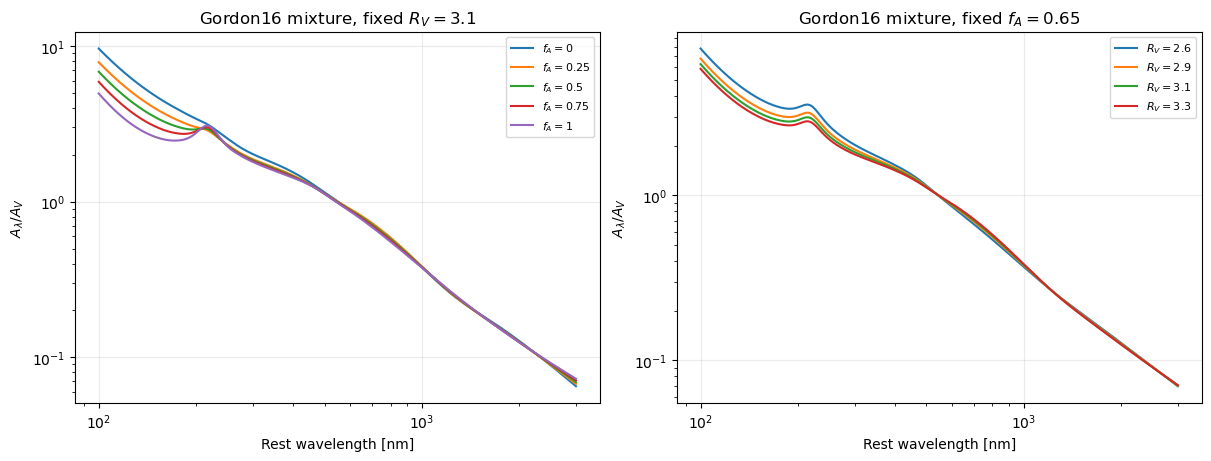

In [4]:
wave_curve_a = jnp.asarray(np.geomspace(1000.0, 30000.0, 800))
wave_curve_nm = np.asarray(wave_curve_a) / 10.0

pure_mw = np.asarray(_gordon16_rvfa_a_over_av(wave_curve_a, rv=jnp.asarray(3.1), f_a=jnp.asarray(1.0)))
pure_f99 = np.asarray(_fitzpatrick99_a_over_av(wave_curve_a, rv=jnp.asarray(3.1)))
pure_smc = np.asarray(_gordon16_rvfa_a_over_av(wave_curve_a, rv=jnp.asarray(3.1), f_a=jnp.asarray(0.0)))
smc_reference = np.asarray(_gordon03_smcbar_a_over_av(wave_curve_a))
print("max |f_A=1 - F99|:", np.max(np.abs(pure_mw - pure_f99)))
print("max |f_A=0 - SMCBar|:", np.max(np.abs(pure_smc - smc_reference)))

rv_test = jnp.asarray(3.1)
fa_test = jnp.asarray(0.65)
rv_a_test = _gordon16_rv_a_from_mixture_rv(rv_test, fa_test)
rv_roundtrip = _gordon16_mixture_rv_from_rv_a(rv_a_test, fa_test)
print("R_V requested:", float(rv_test))
print("derived R(V)_A:", float(rv_a_test))
print("round-trip mixture R_V:", float(rv_roundtrip))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
for f_a in [0.0, 0.25, 0.5, 0.75, 1.0]:
    curve = _gordon16_rvfa_a_over_av(wave_curve_a, rv=jnp.asarray(3.1), f_a=jnp.asarray(f_a))
    axes[0].plot(wave_curve_nm, np.asarray(curve), label=fr"$f_A={f_a:g}$")
axes[0].set_title(r"Gordon16 mixture, fixed $R_V=3.1$")
axes[0].set_xlabel("Rest wavelength [nm]")
axes[0].set_ylabel(r"$A_\lambda / A_V$")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].grid(alpha=0.25)
axes[0].legend(fontsize=8)

for rv in [2.6, 2.9, 3.1, 3.3]:
    curve = _gordon16_rvfa_a_over_av(wave_curve_a, rv=jnp.asarray(rv), f_a=jnp.asarray(0.65))
    axes[1].plot(wave_curve_nm, np.asarray(curve), label=fr"$R_V={rv:g}$")
axes[1].set_title(r"Gordon16 mixture, fixed $f_A=0.65$")
axes[1].set_xlabel("Rest wavelength [nm]")
axes[1].set_ylabel(r"$A_\lambda / A_V$")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].grid(alpha=0.25)
axes[1].legend(fontsize=8)
plt.show()


## 4. Build the Model and Generate One Mock Galaxy

The mock observation is produced by exactly the same backend graph that NUTS will fit. That is intentional: this is a controlled recovery test of the inference machinery and the new dust law, not a simulator-mismatch experiment.


In [5]:
filters = make_broadband_filters()
parameter_space = make_gordon16_parameter_space()
fixed_parameters = fixed_sfh_parameters()

setup_start = time.perf_counter()
ssp_data = load_ssp_templates(fn=str(SSP_FILE))
model, rest_wave_a = build_gordon16_model(ssp_data, filters, parameter_space, fixed_parameters, include_dust=True)
model_no_dust, _ = build_gordon16_model(ssp_data, filters, parameter_space, fixed_parameters, include_dust=False)
setup_seconds = time.perf_counter() - setup_start

truth = parameter_space.from_dict(truth_dict())
initial_theta = parameter_space.from_dict(initial_guess_dict())
theta_truth = jnp.asarray(truth)

predict_photometry_jit = jax.jit(model.predict_photometry)
predict_photometry_batch_jit = jax.jit(jax.vmap(model.predict_photometry))
run_modules_jit = jax.jit(model.run_modules)
run_modules_no_dust_jit = jax.jit(model_no_dust.run_modules)

compile_start = time.perf_counter()
noiseless_flux = np.asarray(block_until_ready(predict_photometry_jit(theta_truth)))
truth_state = block_until_ready(run_modules_jit(theta_truth))
truth_state_no_dust = block_until_ready(run_modules_no_dust_jit(theta_truth))
compile_predict_seconds = time.perf_counter() - compile_start

sigma = RELATIVE_ERROR * np.abs(noiseless_flux) + NOISE_FLOOR_MAGGIES
rng = np.random.default_rng(RNG_SEED)
observed_flux = noiseless_flux + rng.normal(0.0, sigma) if ADD_NOISE_REALIZATION else noiseless_flux.copy()
data = GaussianPhotometricData(observed_flux, sigma)

truth_params = complete_parameter_dict(parameter_space, truth, fixed_parameters)
print(f"setup_seconds = {setup_seconds:.3f}")
print(f"first_jit_predict_seconds = {compile_predict_seconds:.3f}")
print("\nFitted parameters:", parameter_space.names)
print("Fixed SFH parameters:", fixed_parameters)
print("\nTruth:")
for name, value in truth_params.items():
    print(f"  {name:12s} {value: .5f}")
print("  R(V)_A       ", f"{derived_rv_a_numpy(truth_params['R_V'], truth_params['f_A']): .5f}")
print("\nFlux vector shape:", noiseless_flux.shape)
print("Noise model: sigma = relative_error * |flux| + floor")


setup_seconds = 0.012
first_jit_predict_seconds = 1.750

Fitted parameters: ('log10_mass', 'z', 'logzsol', 'A_V', 'R_V', 'f_A')
Fixed SFH parameters: {'tau_gyr': 1.6, 'tage_gyr': 2.0}

Truth:
  tau_gyr       1.60000
  tage_gyr      2.00000
  log10_mass    10.35000
  z             0.72000
  logzsol      -0.35000
  A_V           0.45000
  R_V           3.10000
  f_A           0.65000
  R(V)_A         3.33601

Flux vector shape: (8,)
Noise model: sigma = relative_error * |flux| + floor


## 5. Inspect the Mock Spectrum and Photometry

The first plot shows where the filters sit relative to the generated spectrum. The second plot shows the actual data vector consumed by the likelihood: eight broadband fluxes in maggies.


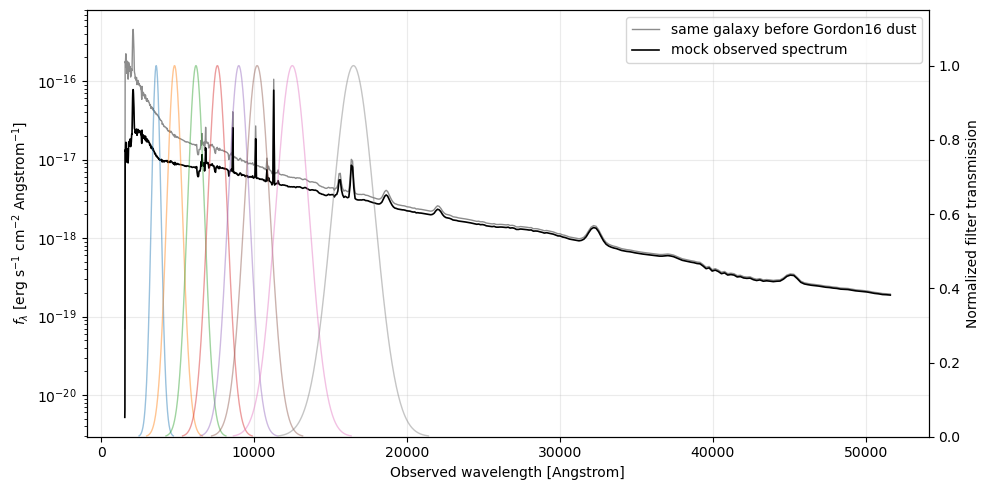

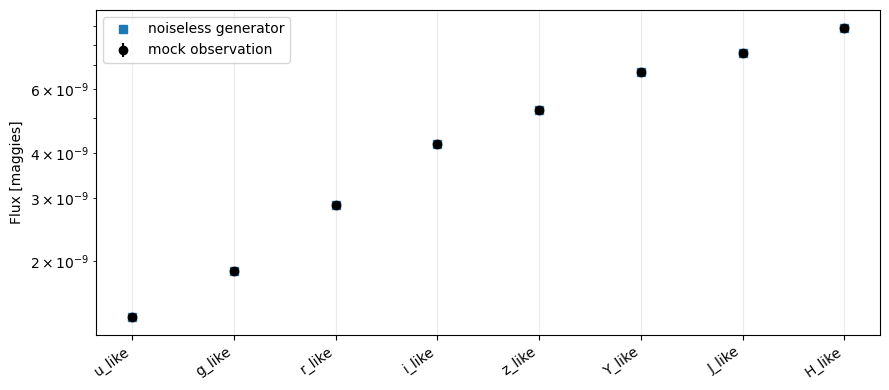

u_like  flux=1.398402e-09 sigma=2.801804e-11 S/N=49.9
g_like  flux=1.874182e-09 sigma=3.753364e-11 S/N=49.9
r_like  flux=2.861482e-09 sigma=5.727964e-11 S/N=50.0
i_like  flux=4.240573e-09 sigma=8.486145e-11 S/N=50.0
z_like  flux=5.247915e-09 sigma=1.050083e-10 S/N=50.0
Y_like  flux=6.695959e-09 sigma=1.339692e-10 S/N=50.0
J_like  flux=7.595924e-09 sigma=1.519685e-10 S/N=50.0
H_like  flux=8.899810e-09 sigma=1.780462e-10 S/N=50.0


In [6]:
wave_obs = np.asarray(truth_state.wave_obs_a)
wave_obs_no_dust = np.asarray(truth_state_no_dust.wave_obs_a)
flam_obs = mass_scaled_observed_flam(truth_state, truth_params)
flam_obs_no_dust = mass_scaled_observed_flam(truth_state_no_dust, truth_params)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(wave_obs_no_dust, flam_obs_no_dust, color="0.55", lw=1.0, label="same galaxy before Gordon16 dust")
ax.plot(wave_obs, flam_obs, color="black", lw=1.2, label="mock observed spectrum")
ax.set_yscale("log")
ax.set_xlabel("Observed wavelength [Angstrom]")
ax.set_ylabel(r"$f_\lambda$ [erg s$^{-1}$ cm$^{-2}$ Angstrom$^{-1}$]")
ax.grid(alpha=0.25)

ax2 = ax.twinx()
for name, wave, trans, valid in zip(filters.names, filters.wavelength_a, filters.transmission, filters.valid):
    w = wave[valid]
    t = trans[valid]
    ax2.plot(w, t / np.max(t), alpha=0.45, lw=1.0)
ax2.set_ylabel("Normalized filter transmission")
ax2.set_ylim(0.0, 1.15)
ax.legend(loc="upper right")
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(filters.names))
ax.errorbar(x, observed_flux, yerr=sigma, fmt="o", color="black", label="mock observation")
ax.plot(x, noiseless_flux, "s", color="tab:blue", label="noiseless generator")
ax.set_xticks(x)
ax.set_xticklabels(filters.names, rotation=35, ha="right")
ax.set_yscale("log")
ax.set_ylabel("Flux [maggies]")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()

for band, flux, err in zip(filters.names, observed_flux, sigma):
    print(f"{band:7s} flux={flux:.6e} sigma={err:.6e} S/N={flux/err:.1f}")


## 6. Run NumPyro NUTS

All parameters are sampled in bounded transformed coordinates internally; the returned samples are in the physical coordinates printed above.


In [7]:
nuts_start = time.perf_counter()
nuts_result = run_numpyro_nuts(
    model,
    data,
    initial_theta=initial_theta,
    num_warmup=NUTS_WARMUP,
    num_samples=NUTS_SAMPLES,
    rng_seed=RNG_SEED + 1,
    progress_bar=True,
    transform_bounds=True,
)
block_until_ready(jnp.asarray(nuts_result.samples))
nuts_seconds = time.perf_counter() - nuts_start
samples = nuts_result.samples
names = tuple(nuts_result.theta_names)

print(f"nuts_seconds = {nuts_seconds:.3f}")
print(f"posterior_samples_per_second = {NUTS_SAMPLES / max(nuts_seconds, 1e-12):.3f}")
print("sample shape:", samples.shape)


  0%|          | 0/90 [00:00<?, ?it/s]

warmup:   4%|▍         | 4/90 [00:02<00:44,  1.91it/s, 1 steps of size 1.07e-03. acc. prob=0.00]

warmup:   9%|▉         | 8/90 [00:08<01:34,  1.15s/it, 511 steps of size 8.84e-05. acc. prob=0.34]

warmup:   9%|▉         | 8/90 [00:20<01:34,  1.15s/it, 511 steps of size 1.53e-04. acc. prob=0.41]

warmup:  11%|█         | 10/90 [00:20<03:29,  2.62s/it, 511 steps of size 2.75e-04. acc. prob=0.47]

...

sample:  98%|█████████▊| 88/90 [08:27<00:09,  4.79s/it, 927 steps of size 1.43e-02. acc. prob=0.79]

sample:  99%|█████████▉| 89/90 [08:39<00:06,  6.83s/it, 1023 steps of size 1.43e-02. acc. prob=0.78]

sample: 100%|██████████| 90/90 [08:41<00:00,  5.45s/it, 159 steps of size 1.43e-02. acc. prob=0.79] 

sample: 100%|██████████| 90/90 [08:41<00:00,  5.80s/it, 159 steps of size 1.43e-02. acc. prob=0.79]

nuts_seconds = 532.257
posterior_samples_per_second = 0.113
sample shape: (60, 6)


## 7. Posterior Summary Metrics

For this controlled test we expect the injected value to sit inside the posterior. The posterior may still show real degeneracies, especially between mass, metallicity, and dust.


In [8]:
def posterior_summary(samples, names, truth):
    q16, q50, q84 = np.quantile(samples, [0.16, 0.5, 0.84], axis=0)
    rows = []
    for i, name in enumerate(names):
        rows.append({
            "name": name,
            "truth": float(truth[i]),
            "q16": float(q16[i]),
            "median": float(q50[i]),
            "q84": float(q84[i]),
            "median_minus_truth": float(q50[i] - truth[i]),
        })
    return rows

summary_rows = posterior_summary(samples, names, truth)
for row in summary_rows:
    print(
        f"{row['name']:12s} truth={row['truth']: .5f} "
        f"median={row['median']: .5f} "
        f"[{row['q16']: .5f}, {row['q84']: .5f}] "
        f"delta={row['median_minus_truth']: .5f}"
    )

rv_a_samples = derived_rv_a_numpy(samples[:, names.index("R_V")], samples[:, names.index("f_A")])
print("\nDerived R(V)_A posterior:")
print("  truth ", derived_rv_a_numpy(truth_params["R_V"], truth_params["f_A"]))
print("  q16/50/84", np.quantile(rv_a_samples, [0.16, 0.5, 0.84]))


log10_mass   truth= 10.35000 median= 10.35306 [ 10.33796,  10.37048] delta= 0.00306
z            truth= 0.72000 median= 0.72760 [ 0.71860,  0.74091] delta= 0.00760
logzsol      truth=-0.35000 median=-0.37846 [-0.51256, -0.18460] delta=-0.02846
A_V          truth= 0.45000 median= 0.42832 [ 0.39121,  0.46257] delta=-0.02168
R_V          truth= 3.10000 median= 2.91034 [ 2.77073,  3.10531] delta=-0.18966
f_A          truth= 0.65000 median= 0.82772 [ 0.57867,  0.91809] delta= 0.17772

Derived R(V)_A posterior:
  truth  3.336012084592145
  q16/50/84 [2.77553302 2.92411145 3.22528484]


## 8. Trace, Marginal, and Corner-Style Diagnostics

This is deliberately not a publication corner plot. It is a quick visual check for stationarity, obvious degeneracies, and whether the truth is in the posterior bulk.


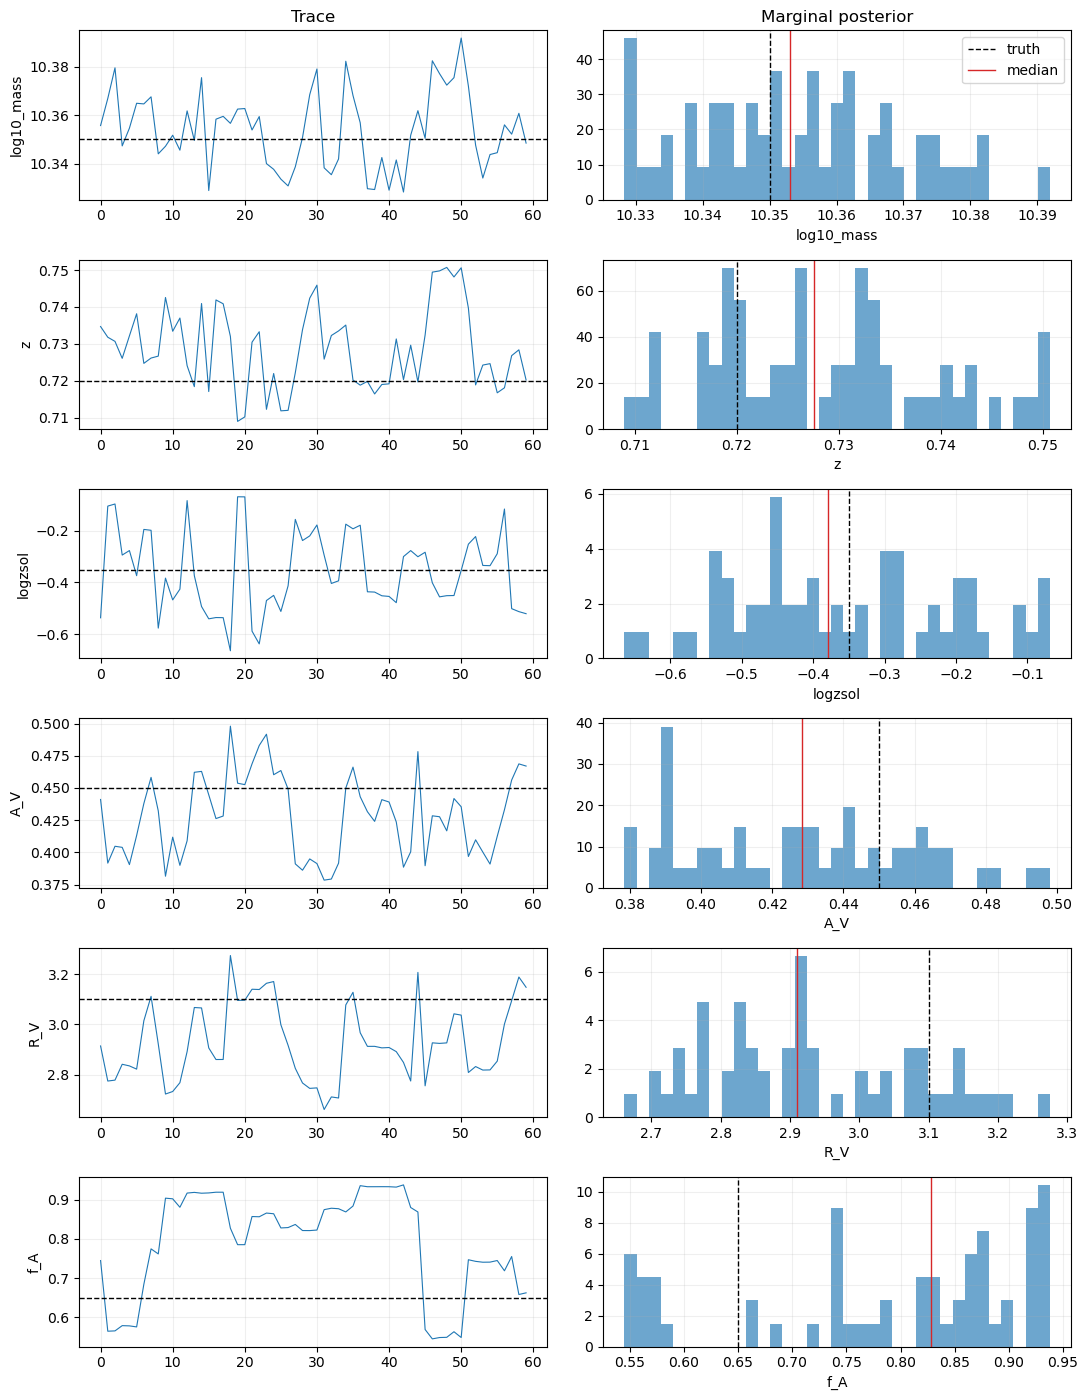

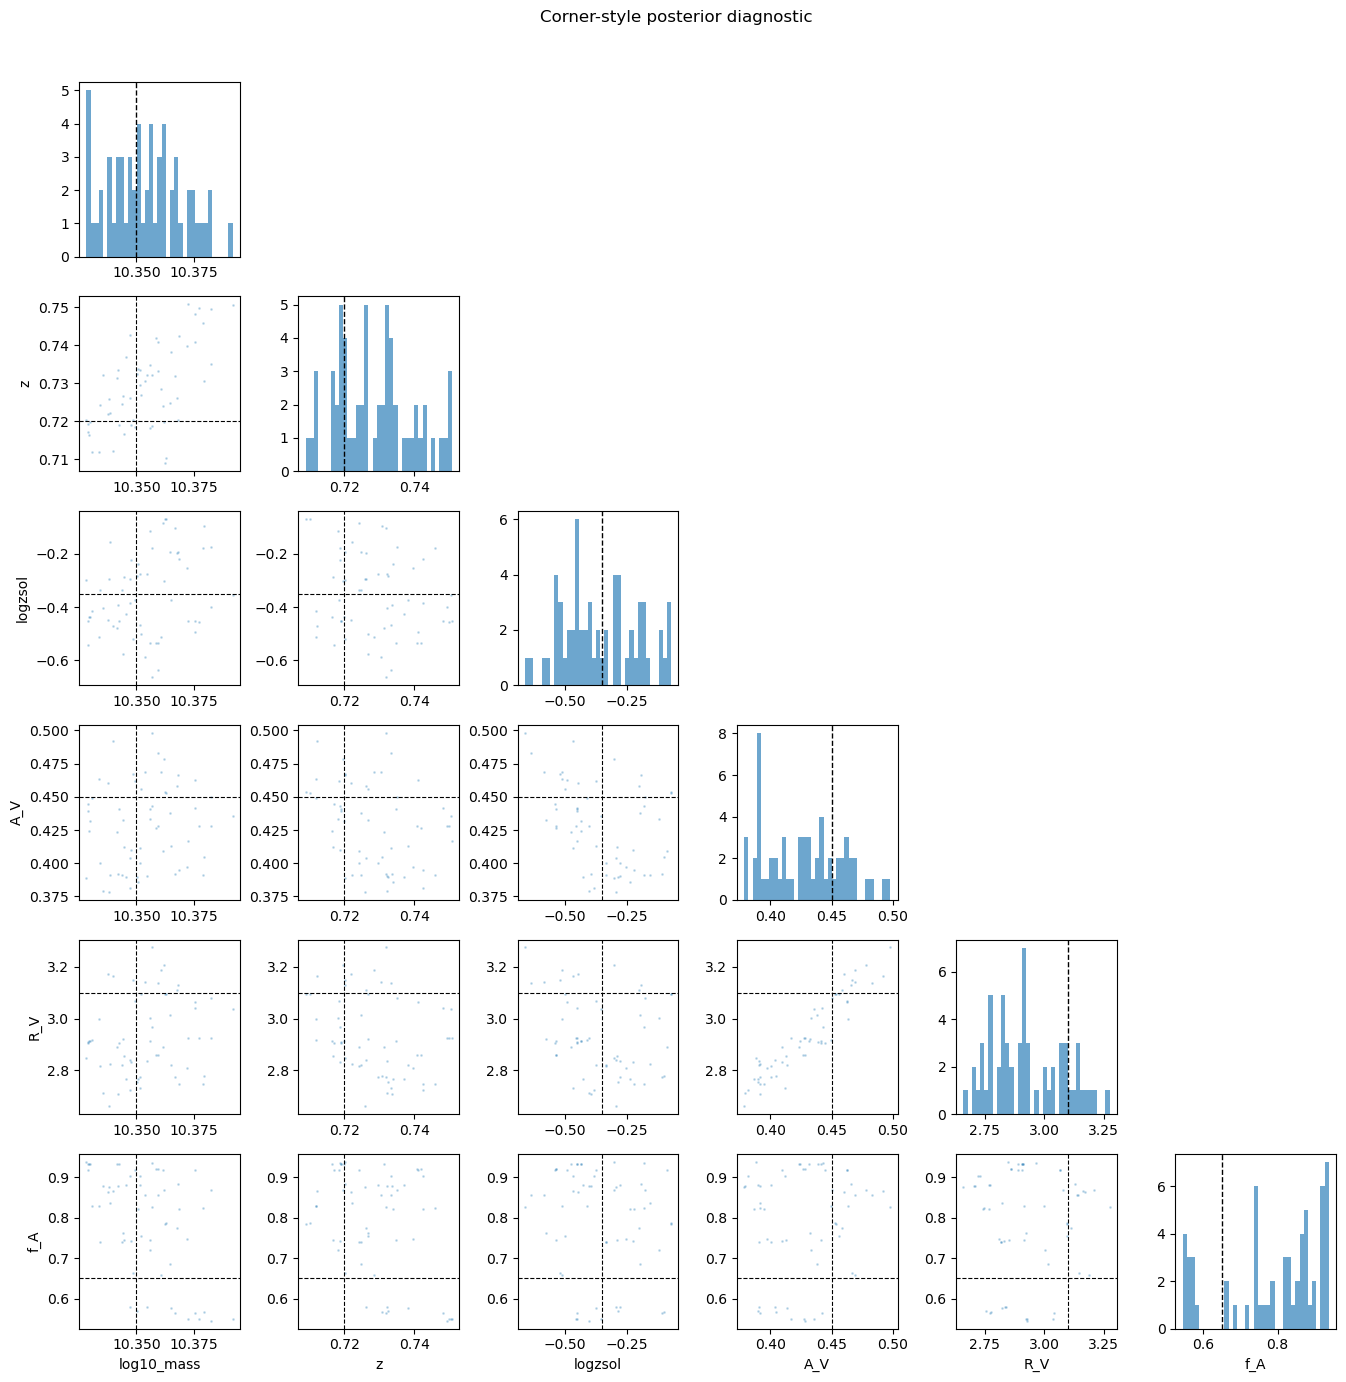

In [9]:
ndim = len(names)

fig, axes = plt.subplots(ndim, 2, figsize=(11, 2.35 * ndim))
if ndim == 1:
    axes = np.asarray([axes])
for i, name in enumerate(names):
    axes[i, 0].plot(samples[:, i], color="tab:blue", lw=0.8)
    axes[i, 0].axhline(truth[i], color="black", ls="--", lw=1.0)
    axes[i, 0].set_ylabel(name)
    axes[i, 0].grid(alpha=0.2)

    axes[i, 1].hist(samples[:, i], bins=35, density=True, color="tab:blue", alpha=0.65)
    axes[i, 1].axvline(truth[i], color="black", ls="--", lw=1.0, label="truth")
    axes[i, 1].axvline(np.median(samples[:, i]), color="tab:red", lw=1.0, label="median")
    axes[i, 1].set_xlabel(name)
    axes[i, 1].grid(alpha=0.2)
axes[0, 0].set_title("Trace")
axes[0, 1].set_title("Marginal posterior")
axes[0, 1].legend()
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(ndim, ndim, figsize=(2.25 * ndim, 2.25 * ndim))
if ndim == 1:
    axes = np.asarray([[axes]])
for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        if i == j:
            ax.hist(samples[:, j], bins=35, color="tab:blue", alpha=0.65)
            ax.axvline(truth[j], color="black", ls="--", lw=1.0)
        elif i > j:
            ax.plot(samples[:, j], samples[:, i], ".", ms=2.0, alpha=0.22, color="tab:blue")
            ax.axvline(truth[j], color="black", ls="--", lw=0.8)
            ax.axhline(truth[i], color="black", ls="--", lw=0.8)
        else:
            ax.axis("off")
        if i == ndim - 1:
            ax.set_xlabel(names[j])
        if j == 0 and i > 0:
            ax.set_ylabel(names[i])
fig.suptitle("Corner-style posterior diagnostic", y=1.02)
fig.tight_layout()
plt.show()


## 9. Photometric Fit and Posterior Predictive Fluxes

The posterior predictive band fluxes should cover the mock data vector. This uses the same active data vector as the likelihood: the eight broadband fluxes.


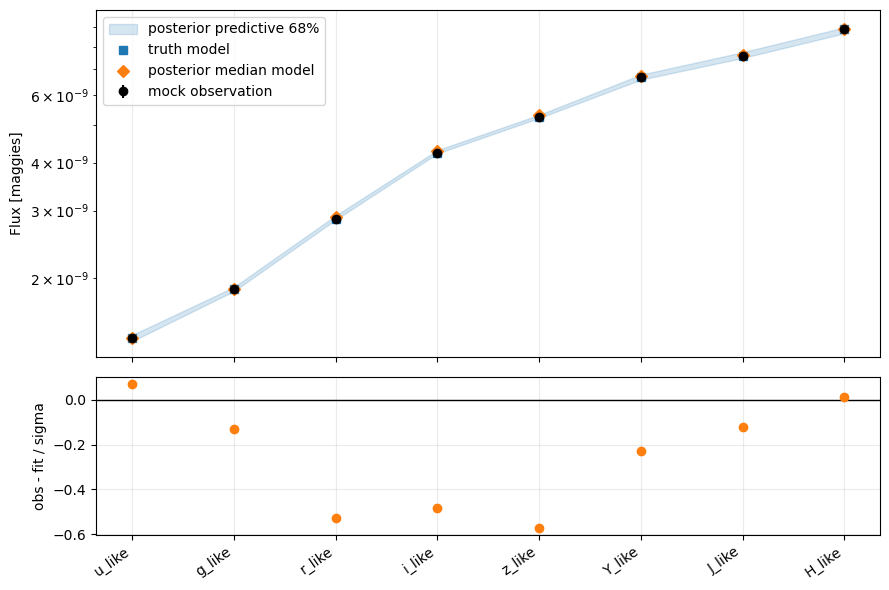

chi2 at posterior median: 0.9225688996076411
posterior_predictive_seconds for 60 models = 1.766


In [10]:
median_theta = np.median(samples, axis=0)
median_flux = np.asarray(block_until_ready(predict_photometry_jit(jnp.asarray(median_theta))))
residual_sigma = (observed_flux - median_flux) / sigma

rng = np.random.default_rng(RNG_SEED + 123)
posterior_indices = rng.choice(samples.shape[0], size=min(N_POSTERIOR_PREDICTIVE, samples.shape[0]), replace=False)
posterior_start = time.perf_counter()
posterior_fluxes = np.asarray(block_until_ready(predict_photometry_batch_jit(jnp.asarray(samples[posterior_indices]))))
posterior_predictive_seconds = time.perf_counter() - posterior_start
flux_q16, flux_q50, flux_q84 = np.quantile(posterior_fluxes, [0.16, 0.5, 0.84], axis=0)

fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(9, 6), sharex=True, gridspec_kw={"height_ratios": [2.2, 1.0]})
x = np.arange(len(filters.names))
ax0.fill_between(x, flux_q16, flux_q84, color="tab:blue", alpha=0.18, label="posterior predictive 68%")
ax0.errorbar(x, observed_flux, yerr=sigma, fmt="o", color="black", label="mock observation")
ax0.plot(x, noiseless_flux, "s", color="tab:blue", label="truth model")
ax0.plot(x, median_flux, "D", color="tab:orange", label="posterior median model")
ax0.set_yscale("log")
ax0.set_ylabel("Flux [maggies]")
ax0.grid(alpha=0.25)
ax0.legend()

ax1.axhline(0.0, color="black", lw=1.0)
ax1.plot(x, residual_sigma, "o", color="tab:orange")
ax1.set_ylabel("obs - fit / sigma")
ax1.set_xticks(x)
ax1.set_xticklabels(filters.names, rotation=35, ha="right")
ax1.grid(alpha=0.25)
fig.tight_layout()
plt.show()

print("chi2 at posterior median:", float(np.sum(residual_sigma**2)))
print(f"posterior_predictive_seconds for {posterior_fluxes.shape[0]} models = {posterior_predictive_seconds:.3f}")


## 10. Spectrum Comparison: Truth vs Posterior Median

The likelihood only saw broadband photometry. The spectrum comparison is therefore a diagnostic, not a fitted observable.


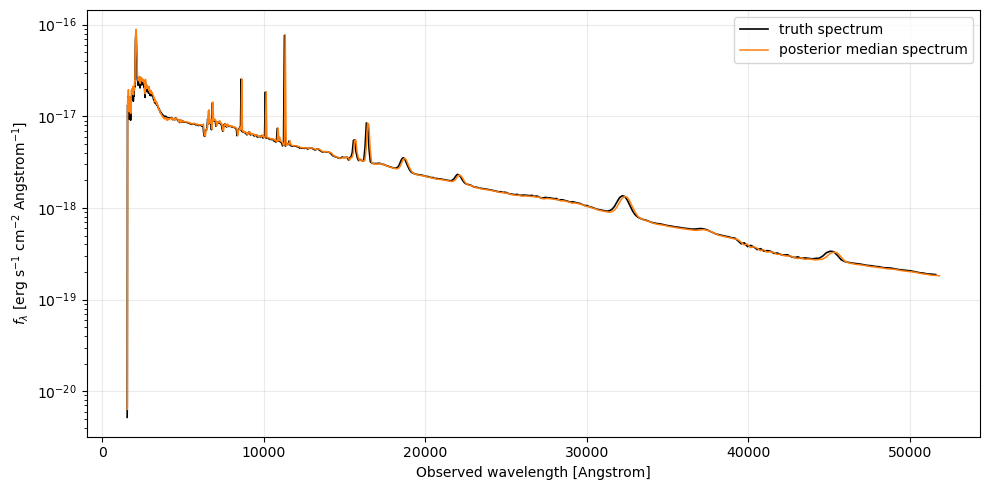

In [11]:
median_state = block_until_ready(run_modules_jit(jnp.asarray(median_theta)))
median_params = complete_parameter_dict(parameter_space, median_theta, fixed_parameters)
wave_med = np.asarray(median_state.wave_obs_a)
flam_med = mass_scaled_observed_flam(median_state, median_params)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(wave_obs, flam_obs, color="black", lw=1.2, label="truth spectrum")
ax.plot(wave_med, flam_med, color="tab:orange", lw=1.1, label="posterior median spectrum")
ax.set_yscale("log")
ax.set_xlabel("Observed wavelength [Angstrom]")
ax.set_ylabel(r"$f_\lambda$ [erg s$^{-1}$ cm$^{-2}$ Angstrom$^{-1}$]")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()


## 11. Save Outputs

The saved file is intentionally small: posterior samples, mock data, posterior predictive fluxes, and enough metadata to remake the summary plots.


In [12]:
summary = {row["name"]: {k: v for k, v in row.items() if k != "name"} for row in summary_rows}
npz_path = OUTPUT_DIR / "jaxcigale_gordon16_nuts_samples.npz"
json_path = OUTPUT_DIR / "jaxcigale_gordon16_nuts_summary.json"

np.savez(
    npz_path,
    samples=samples,
    log_prob=nuts_result.log_prob,
    truth=truth,
    median_theta=median_theta,
    noiseless_flux_maggies=noiseless_flux,
    observed_flux_maggies=observed_flux,
    sigma_maggies=sigma,
    median_flux_maggies=median_flux,
    posterior_fluxes_maggies=posterior_fluxes,
    band_names=np.asarray(filters.names),
    theta_names=np.asarray(names),
    rv_a_samples=rv_a_samples,
    fixed_parameter_names=np.asarray(list(fixed_parameters.keys())),
    fixed_parameter_values=np.asarray(list(fixed_parameters.values())),
)

json_path.write_text(json.dumps({
    "ssp_file": str(SSP_FILE),
    "jax_backend": jax.default_backend(),
    "jax_devices": [str(device) for device in jax.devices()],
    "jax_default_float_dtype": str(np.asarray(jnp.asarray(1.0)).dtype),
    "theta_names": list(names),
    "band_names": list(filters.names),
    "fixed_parameters": fixed_parameters,
    "relative_error": RELATIVE_ERROR,
    "noise_floor_maggies": NOISE_FLOOR_MAGGIES,
    "noise_realization": ADD_NOISE_REALIZATION,
    "derived_truth_rv_a": float(derived_rv_a_numpy(truth_params["R_V"], truth_params["f_A"])),
    "timings": {
        "setup_seconds": setup_seconds,
        "first_jit_predict_seconds": compile_predict_seconds,
        "nuts_seconds": nuts_seconds,
        "posterior_samples_per_second": NUTS_SAMPLES / max(nuts_seconds, 1.0e-12),
        "posterior_predictive_seconds": posterior_predictive_seconds,
    },
    "summary": summary,
}, indent=2) + "\n")

print("saved", npz_path)
print("saved", json_path)


saved outputs/experimental_jaxcigale_nuts_assessment/jaxcigale_gordon16_nuts_samples.npz
saved outputs/experimental_jaxcigale_nuts_assessment/jaxcigale_gordon16_nuts_summary.json


## 12. Checklist

- **Data entering:** one mock broadband flux vector in maggies, generated from the same JAX-CIGALE model.
- **Transformations:** delayed SFH on cosmic time → DSPS stellar spectrum → Gordon16 extinction → Madau-like IGM → redshift → filter integration.
- **Units:** internal rest wavelengths are Angstrom; luminosity density is `Lsun / Angstrom`; observed flux density is cgs `f_lambda`; fitted photometry is maggies.
- **Masks/cuts:** no band mask in this toy test; all eight broadbands are active.
- **Normalization:** DSPS spectrum is per solar mass formed; `log10_mass` is applied exactly once in `JaxSedModel.predict_photometry`.
- **Final quantity:** posterior samples for `(log10_mass, z, logzsol, A_V, R_V, f_A)`.
- **Most important functions to check:** `build_gordon16_model`, `make_gordon16_parameter_space`, `_gordon16_rvfa_a_over_av`, and `run_numpyro_nuts`.
- **Sanity checks:** Gordon16 limiting cases, posterior recovery of injected values, posterior predictive flux residuals, and the spectrum comparison.
